In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('data/income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


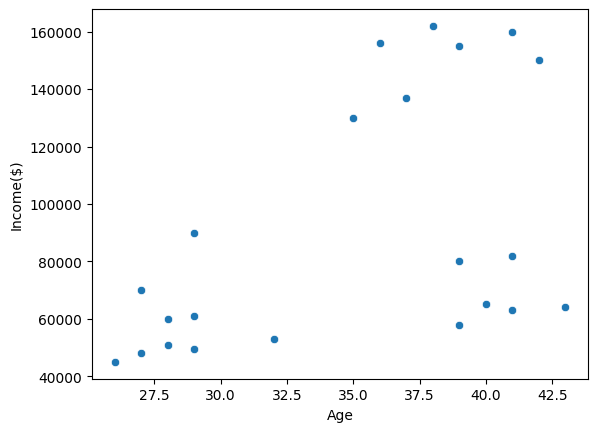

In [6]:
sns.scatterplot(x='Age',y='Income($)',data=df)
plt.show()

# Hierarchical Clustring from SKlearn

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg=AgglomerativeClustering(
    n_clusters=3,       # Number of clusters
    metric='euclidean', # Distance measure between data points
    linkage='ward',     # Method used to calculate distance between clusters
    distance_threshold=None, # Distance at which clustering stops
    compute_full_tree='auto' # Whether to build the complete tree
)
agg.fit(df[['Age','Income($)']])
agg.labels_

array([1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1])

In [17]:
df['cluster']=agg.labels_
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,1
1,Michael,29,90000,2
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,0


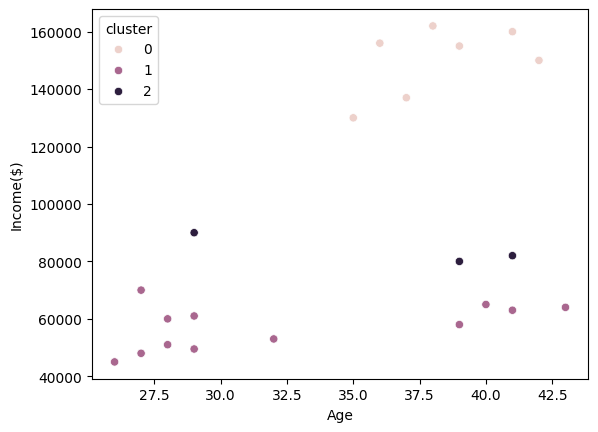

In [18]:
sns.scatterplot(x='Age',y='Income($)',hue='cluster',data=df)
plt.show()

# Hirarchical clustring from Scipy

In [ ]:
from scipy.cluster.hierarchy import linkage,dendrogram,fcluster
x=df[['Age','Income($)']]
z=linkage(x,
    method='ward',      # How clusters are merged
    metric='euclidean'  # Distance measure
)
z

array([[2.00000000e+00, 3.00000000e+00, 1.00000050e+03, 2.00000000e+00],
       [1.70000000e+01, 1.80000000e+01, 1.00000200e+03, 2.00000000e+00],
       [5.00000000e+00, 8.00000000e+00, 1.00000450e+03, 2.00000000e+00],
       [1.30000000e+01, 1.40000000e+01, 1.50000033e+03, 2.00000000e+00],
       [1.60000000e+01, 2.30000000e+01, 1.50000237e+03, 3.00000000e+00],
       [1.90000000e+01, 2.00000000e+01, 2.00000100e+03, 2.00000000e+00],
       [6.00000000e+00, 7.00000000e+00, 2.00000225e+03, 2.00000000e+00],
       [1.20000000e+01, 2.50000000e+01, 2.25000075e+03, 3.00000000e+00],
       [2.10000000e+01, 2.20000000e+01, 2.50002346e+03, 3.00000000e+00],
       [1.50000000e+01, 2.90000000e+01, 3.50000260e+03, 4.00000000e+00],
       [2.60000000e+01, 3.00000000e+01, 4.33335070e+03, 6.00000000e+00],
       [1.10000000e+01, 3.10000000e+01, 5.37500094e+03, 5.00000000e+00],
       [2.40000000e+01, 2.80000000e+01, 5.50000098e+03, 4.00000000e+00],
       [9.00000000e+00, 1.00000000e+01, 7.00000029e

## manually calculating Euclidean distance

In [33]:
np.sqrt((29-28)**2+(9000-6000)**2)

np.float64(3000.000166666662)

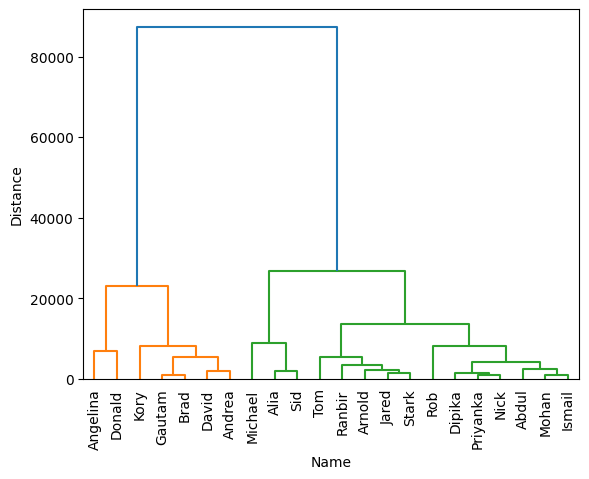

In [23]:
dendrogram(z,labels=df['Name'].values,leaf_rotation=90,leaf_font_size=10)
plt.xlabel('Name')
plt.ylabel('Distance')
plt.show()

In [36]:
fc=fcluster(z,t=3,criterion='maxclust')
fc

array([3, 2, 3, 3, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3],
      dtype=int32)

In [37]:
df['cluster']=fc

In [38]:
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,3
1,Michael,29,90000,2
2,Mohan,29,61000,3
3,Ismail,28,60000,3
4,Kory,42,150000,1


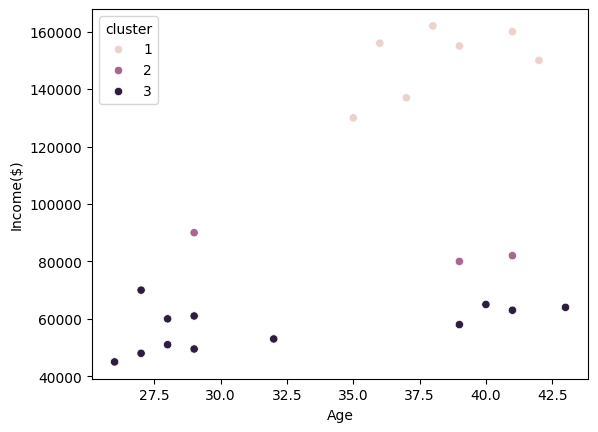

In [43]:
sns.scatterplot(x='Age',y='Income($)',hue='cluster',data=df)
plt.show()